# Ethiopia Seasonal Mask

In [169]:
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.io.shapereader as shpreader
from shapely import contains_xy
import dask


## Parameters
Set these and rerun downstream cells.

In [170]:
# Data + years
data_dir = Path("data/CHIRPS")
output_dir = Path("data")
start_year = 1998
end_year = 2013
var_name = "precip"

# Season months (list of month numbers)
# MAM  = [3, 4, 5]
# JJAS = [6, 7, 8, 9]
# OND  = [10, 11, 12]
season_months = [6, 7, 8, 9]

# Mask logic mode:
# 1 = Rainfall in selected season >= threshold_mm
# 2 = Selected season contains >= majority_fraction of annual rainfall
mask_mode = 1

threshold_mm = 100.0
majority_fraction = 0.5

In [171]:
years = list(range(start_year, end_year + 1))
files = [data_dir / f"{y}.nc" for y in years]
existing_files = [str(f) for f in files if f.exists()]

In [172]:
ds_chirps = xr.open_mfdataset(
    existing_files,
    combine="by_coords",
    parallel=True,
    engine="netcdf4",
    chunks={"time": 12},
)

rename_map = {}
for old, new in [
    ("TIME", "time"),
    ("LATITUDE", "lat"),
    ("LONGITUDE", "lon"),
    ("latitude", "lat"),
    ("longitude", "lon"),
]:
    if old in ds_chirps.dims or old in ds_chirps.coords:
        rename_map[old] = new

if rename_map:
    ds_chirps = ds_chirps.rename(rename_map)

print("Dims:", ds_chirps.dims)
print("Vars:", list(ds_chirps.data_vars))

ds_chirps = ds_chirps.sel(lat=slice(2, 16.5), lon=slice(32, 49))
ds_chirps = ds_chirps.chunk({"time": 12, "lat": 200, "lon": 200})


Dims: FrozenMappingWarningOnValuesAccess({'time': 5844, 'lat': 49, 'lon': 61})
Vars: ['precip']


In [173]:
selected_months = sorted({int(m) for m in season_months})
for m in selected_months:
    if m < 1 or m > 12:
        raise ValueError(f"Invalid month in season_months: {m}. Must be 1..12")

ds_years = ds_chirps.sel(time=ds_chirps["time.year"].isin(np.array(years)))
da = ds_years[var_name]
season_da = da.sel(time=da["time.month"].isin(selected_months))
seasonal_total_clim = season_da.groupby("time.year").sum("time").mean("year")
annual_total_clim = da.groupby("time.year").sum("time").mean("year")
seasonal_fraction = seasonal_total_clim / annual_total_clim

if mask_mode == 1:
    seasonal_mask = seasonal_total_clim >= float(threshold_mm)
else:
    seasonal_mask = seasonal_fraction >= float(majority_fraction)


month_initial = {1: "J", 2: "F", 3: "M", 4: "A", 5: "M", 6: "J", 7: "J", 8: "A", 9: "S", 10: "O", 11: "N", 12: "D"}
season_label = "".join(month_initial[m] for m in selected_months)
filename_slug = f"chirps_v3_ethiopia_mask_{years[0]}_{years[-1]}.nc"

print("Season label:", season_label)
print("Output filename:", filename_slug)


Season label: JJAS
Output filename: chirps_v3_ethiopia_mask_1998_2013.nc


In [174]:
ethiopia_shp = shpreader.natural_earth(
    resolution="10m", category="cultural", name="admin_0_countries"
)
ethiopia_geom = None
for country in shpreader.Reader(ethiopia_shp).records():
    if country.attributes["NAME"] == "Ethiopia":
        ethiopia_geom = country.geometry
        break
if ethiopia_geom is None:
    raise RuntimeError("Could not find Ethiopia geometry in Natural Earth data.")

lons, lats = np.meshgrid(seasonal_mask.lon.values, seasonal_mask.lat.values)
mask_flat = contains_xy(ethiopia_geom, lons.ravel(), lats.ravel())
ethiopia_grid_mask = mask_flat.reshape(lons.shape)
seasonal_mask_ethiopia = seasonal_mask.where(ethiopia_grid_mask)


In [ ]:
# Compute climatological daily-mean precipitation for selected season.
# Works for both daily and monthly inputs.

time_days = season_da["time"].diff("time").dt.days
median_step_days = float(time_days.median().item()) if time_days.size > 0 else 1.0

if median_step_days <= 1.5:
    # Daily data
    daily_mean_precip = season_da.mean("time")
    timestep_note = "daily input"
else:
    # Monthly data; convert to daily mean
    seasonal_total_by_year = season_da.groupby("time.year").sum("time")
    days_by_year = season_da["time"].dt.days_in_month.groupby("time.year").sum("time")
    daily_mean_precip = (seasonal_total_by_year / days_by_year).mean("year")
    timestep_note = "monthly input"

# Keep precip only where mask is active (inside Ethiopia + logic=True)
mask_true = seasonal_mask_ethiopia.fillna(0) > 0
daily_mean_precip_masked = daily_mean_precip.where(mask_true)

print(f"Daily mean mode: {timestep_note}; median timestep ~ {median_step_days:.2f} day(s)")


Daily mean mode: daily input; median timestep ~ 1.00 day(s)


In [ ]:
seasonal_mask_ethiopia, daily_mean_precip_masked = dask.compute(
    seasonal_mask_ethiopia, daily_mean_precip_masked
)

print("seasonal_mask_ethiopia", seasonal_mask_ethiopia.shape)
print("daily_mean_precip_masked", daily_mean_precip_masked.shape)


seasonal_mask_ethiopia (49, 61)
daily_mean_precip_masked (49, 61)


## Plot masked daily mean precip

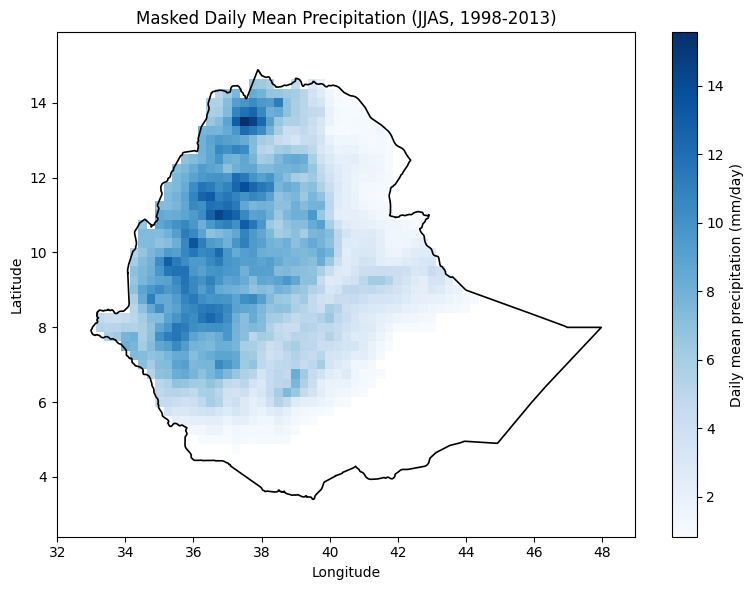

In [177]:
fig, ax = plt.subplots(figsize=(8, 6))
daily_mean_precip_masked.plot(
    ax=ax,
    cmap="Blues",
    cbar_kwargs={"label": "Daily mean precipitation (mm/day)"},
    #robust=True
)

# Ethiopia boundary
geoms = ethiopia_geom.geoms if hasattr(ethiopia_geom, "geoms") else [ethiopia_geom]
for geom in geoms:
    x, y = geom.exterior.xy
    ax.plot(x, y, color="black", linewidth=1.2)

# Zoom to Ethiopia
minx, miny, maxx, maxy = ethiopia_geom.bounds
pad = 1.0
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

ax.set_title(f"Masked Daily Mean Precipitation ({season_label}, {years[0]}-{years[-1]})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.tight_layout()
plt.show()


## Export NetCDF mask

In [179]:
resolved_output = output_dir / filename_slug

seasonal_mask_ethiopia_ds = xr.Dataset(
    {
        "seasonal_mask": (["lat", "lon"], seasonal_mask_ethiopia.astype("float32").values)
    },
    coords={"lat": seasonal_mask_ethiopia.lat, "lon": seasonal_mask_ethiopia.lon},
)

seasonal_mask_ethiopia_ds["seasonal_mask"].attrs["long_name"] = (
    f"{season_label} seasonal mask for Ethiopia"
)
seasonal_mask_ethiopia_ds["seasonal_mask"].attrs["description"] = (
    "Binary mask where 1 indicates cells meeting selected logic within Ethiopia boundaries, "
    "0 or NaN elsewhere."
)
seasonal_mask_ethiopia_ds.attrs["source"] = "Derived from CHIRPS v3 seasonal analysis"
seasonal_mask_ethiopia_ds.attrs['resolution'] = '0.25 degrees'
seasonal_mask_ethiopia_ds.attrs["mask_logic"] = "majority rainfall" if mask_mode else f"threshold, >={threshold_mm}" 

resolved_output.parent.mkdir(parents=True, exist_ok=True)
seasonal_mask_ethiopia_ds.to_netcdf(resolved_output)
print("Saved:", resolved_output)

Saved: data/chirps_v3_ethiopia_mask_1998_2013.nc
